<a href="https://colab.research.google.com/github/juanjosedelgado-coder/Talleres/blob/main/Taller_PCA_Delgado_Vargas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/LinaMariaCastro/curso-ia-para-economia/blob/main/clases/4_Aprendizaje_no_supervisado/3_Taller_PCA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



# **Inteligencia Artificial con Aplicaciones en Economía I**

- 👩‍🏫 **Profesora:** [Lina María Castro](https://www.linkedin.com/in/lina-maria-castro)  
- 📧 **Email:** [lmcastroco@gmail.com](mailto:lmcastroco@gmail.com)  
- 🎓 **Universidad:** Universidad Externado de Colombia - Facultad de Economía

# **Taller: Creación de un Índice de Clima de Inversión con Análisis de Componentes Principales (PCA)**

**IMPORTANTE**: Guarda una copia de este notebook en tu Google Drive o computador.

**Taller en grupos de 3**

**Nombres estudiantes:**

- Natalia Vargas
- Juan Jose Delgado
-

**Forma de entrega:**

- Nombrar el archivo de la siguiente forma:“Taller_PCA_apellidos.ipynb”.
- Suba el Jupyter Notebook a su cuenta en Github y envíe el link en el siguiente Forms: https://forms.cloud.microsoft/r/q1ZSe3N80C.

**IMPORTANTE:** No se recibirán talleres en Google Colab, el notebook debe estar subido en Github.

**Plazo de entrega:**

28 de abril de 2026, máximo a las 11:59 p.m. Tenga en cuenta que luego de esa hora el formulario en forms se cierra. El Jupupyter Notebook también debe quedar subido en Github antes de esa hora.

**Instrucciones Generales:**

Completa el código en las celdas marcadas con `### TU CÓDIGO AQUÍ ###`. Puedes añadir más celdas si lo requieres.

### Contexto

**Escenario:** Eres un científico de datos recién contratado como consultor experto por el **Ministerio de Comercio, Industria y Turismo (MinCIT)** de Colombia. Tu tarea principal es crear un **'Índice de Clima para la Inversión'** cuantitativo que permita clasificar y comparar el entorno competitivo de los países de América Latina y el Caribe. Este índice orientará las estrategias de integración regional y las políticas para atraer Inversión Extranjera Directa (IED).

**Objetivo:** Utilizando la base de datos de indicadores provista (preparada para este análisis) y la técnica de **Análisis de Componentes Principales (PCA)**, deberás extraer la "variable latente" que resume el clima de inversión, interpretar sus pesos económicos y presentar un ranking de países con recomendaciones ejecutivas.


## Ejercicio 1: Configuración Inicial, Carga y Exploración de Datos

1.1 Importa las librerías necesarias

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

In [29]:
# Configuraciones de visualización
pd.options.display.max_columns = None
pd.options.display.float_format = '{:,.2f}'.format
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

1.2 Carga el dataset "Indicators.csv" que se encuentra en el repositorio del curso, carpeta "datasets". El dataframe debe llamarse "df_indicators".

In [30]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [31]:
df_indicators = pd.read_csv('/content/drive/MyDrive/IA Economia/Indicators.csv')

In [32]:
# Debe ser (121, 4)
print("Dimensiones del DataFrame Indicators:")
print(df_indicators.shape)

Dimensiones del DataFrame Indicators:
(121, 4)


In [33]:
print("\nInformación general del DataFrame:")
df_indicators.info()


Información general del DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 121 entries, 0 to 120
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   CountryCode    121 non-null    object 
 1   IndicatorCode  121 non-null    object 
 2   Year           121 non-null    int64  
 3   Value          121 non-null    float64
dtypes: float64(1), int64(1), object(2)
memory usage: 3.9+ KB


1.3 Carga el dataset "Country.csv" que se encuentra en el repositorio del curso, carpeta "datasets". El dataframe debe llamarse "df_countries".

In [34]:
df_countries = pd.read_csv('/content/drive/MyDrive/IA Economia/Country.csv')

In [35]:
# Debe ser (14, 3)
print("Dimensiones del DataFrame Countries:")
print(df_countries.shape)

Dimensiones del DataFrame Countries:
(14, 3)


In [36]:
print("\nInformación general del DataFrame:")
df_countries.info()


Información general del DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   CountryCode  14 non-null     object
 1   ShortName    14 non-null     object
 2   Region       14 non-null     object
dtypes: object(3)
memory usage: 468.0+ bytes


### Ejercicio 2: Selección y Preparación de Datos

Para el análisis del MinCIT, hemos preseleccionado un conjunto de variables clave.

2.1. Utiliza el diccionario para modificar los códigos de los indicadores por sus descripciones

In [37]:
nombre_indicadores = {
    'NV.AGR.TOTL.ZS': 'Agricultura (% del PIB)',
    'NE.TRD.GNFS.ZS': 'Comercio (% del PIB)',
    'NY.GDP.MKTP.KD.ZG': 'Crecimiento del PIB (%)',
    'FP.CPI.TOTL.ZG': 'Inflación (%)',
    'GC.DOD.TOTL.GD.ZS': 'Deuda del gob. central (% del PIB)',
    'SE.XPD.TOTL.GD.ZS': 'Gasto en educación (% del PIB)',
    'SH.XPD.CHEX.GD.ZS': 'Gasto en salud (% del PIB)',
    'IQ.CPA.BREG.XQ': 'Facilidad para hacer negocios',
    'IC.LGL.DURS': 'Días para cumplir contratos',
    'TX.VAL.MRCH.XD.WD': 'Exportaciones (US$)',
    'TM.VAL.MRCH.XD.WD': 'Importaciones (US$)'
}

In [38]:
df_indicators['IndicatorName'] = df_indicators['IndicatorCode'].map(nombre_indicadores)
df_indicators.head()

,CountryCode,IndicatorCode,Year,Value,IndicatorName
0,CHL,NV.AGR.TOTL.ZS,2014,6.75,Agricultura (% del PIB)
1,CHL,NE.TRD.GNFS.ZS,2014,74.31,Comercio (% del PIB)
2,CHL,NY.GDP.MKTP.KD.ZG,2014,7.65,Crecimiento del PIB (%)
3,CHL,FP.CPI.TOTL.ZG,2014,12.62,Inflación (%)
4,CHL,GC.DOD.TOTL.GD.ZS,2014,42.83,Deuda del gob. central (% del PIB)


2.2. Utiliza pivot table para crear un nuevo dataframe donde se encuentren los países como filas y los indicadores como columnas. Llama a este dataframe "df_pivot". No olvides colocar .reset_index() para que la columna de código de países quede como una columna y no como el índice.

In [39]:
df_pivot = df_indicators.pivot_table(index='CountryCode', columns='IndicatorName', values='Value').reset_index()
df_pivot.head()

IndicatorName,CountryCode,Agricultura (% del PIB),Comercio (% del PIB),Crecimiento del PIB (%),Deuda del gob. central (% del PIB),Días para cumplir contratos,Exportaciones (US$),Facilidad para hacer negocios,Gasto en educación (% del PIB),Gasto en salud (% del PIB),Importaciones (US$),Inflación (%)
0,ARG,11.73,32.43,-0.45,73.07,873.48,"20,153,725,105.95",2.19,2.38,4.09,"18,058,208,718.45",44.28
1,BOL,NaN,54.39,1.76,66.69,798.96,"39,036,984,373.93",NaN,5.37,5.05,"36,977,180,000.81",36.05
2,BRA,12.79,60.18,2.59,57.20,741.68,"56,043,860,610.92",3.57,4.56,5.31,"50,026,448,161.33",25.60
3,CHL,6.75,74.31,7.65,42.83,535.92,"90,542,560,043.59",5.88,6.38,8.29,"80,536,582,307.19",12.62
4,COL,6.92,59.96,6.60,47.95,633.90,NaN,NaN,6.34,6.30,"67,424,196,254.97",11.61


2.3. Crea el dataframe "df_final", realizando un merge entre "df_pivot" y "df_countries" con el fin de agregar el nombre de los países.

In [40]:
df_final = pd.merge(df_pivot, df_countries, on='CountryCode', how = 'left')
df_final.head()

,CountryCode,Agricultura (% del PIB),Comercio (% del PIB),Crecimiento del PIB (%),Deuda del gob. central (% del PIB),Días para cumplir contratos,Exportaciones (US$),Facilidad para hacer negocios,Gasto en educación (% del PIB),Gasto en salud (% del PIB),Importaciones (US$),Inflación (%),ShortName,Region
0,ARG,11.73,32.43,-0.45,73.07,873.48,"20,153,725,105.95",2.19,2.38,4.09,"18,058,208,718.45",44.28,Argentina,Latin America & Caribbean
1,BOL,NaN,54.39,1.76,66.69,798.96,"39,036,984,373.93",NaN,5.37,5.05,"36,977,180,000.81",36.05,Bolivia,Latin America & Caribbean
2,BRA,12.79,60.18,2.59,57.20,741.68,"56,043,860,610.92",3.57,4.56,5.31,"50,026,448,161.33",25.60,Brasil,Latin America & Caribbean
3,CHL,6.75,74.31,7.65,42.83,535.92,"90,542,560,043.59",5.88,6.38,8.29,"80,536,582,307.19",12.62,Chile,Latin America & Caribbean
4,COL,6.92,59.96,6.60,47.95,633.90,NaN,NaN,6.34,6.30,"67,424,196,254.97",11.61,Colombia,Latin America & Caribbean


2.4. Elimina las columnas "Region" y "CountryCode" y establece la columna 'ShortName' como el índice del dataframe

In [41]:
df_final = df_final.drop(columns=['Region', 'CountryCode'])
df_final = df_final.set_index('ShortName')
df_final.head()

,Agricultura (% del PIB),Comercio (% del PIB),Crecimiento del PIB (%),Deuda del gob. central (% del PIB),Días para cumplir contratos,Exportaciones (US$),Facilidad para hacer negocios,Gasto en educación (% del PIB),Gasto en salud (% del PIB),Importaciones (US$),Inflación (%)
ShortName,,,,,,,,,,,
Argentina,11.73,32.43,-0.45,73.07,873.48,"20,153,725,105.95",2.19,2.38,4.09,"18,058,208,718.45",44.28
Bolivia,NaN,54.39,1.76,66.69,798.96,"39,036,984,373.93",NaN,5.37,5.05,"36,977,180,000.81",36.05
Brasil,12.79,60.18,2.59,57.20,741.68,"56,043,860,610.92",3.57,4.56,5.31,"50,026,448,161.33",25.60
Chile,6.75,74.31,7.65,42.83,535.92,"90,542,560,043.59",5.88,6.38,8.29,"80,536,582,307.19",12.62
Colombia,6.92,59.96,6.60,47.95,633.90,NaN,NaN,6.34,6.30,"67,424,196,254.97",11.61


### Ejercicio 3: Limpieza de Datos (Imputación de Valores Faltantes)

En la vida real de un economista, los datos tienen huecos. El PCA requiere bases completas. Usaremos una estrategia de imputación por la media para resolver los NaN.

3.1. Revisa cuántos valores faltantes hay en cada columna

In [42]:
print("Valores faltantes por columna:")
print(df_final.isnull().sum())

Valores faltantes por columna:
Agricultura (% del PIB)               4
Comercio (% del PIB)                  3
Crecimiento del PIB (%)               0
Deuda del gob. central (% del PIB)    4
Días para cumplir contratos           2
Exportaciones (US$)                   3
Facilidad para hacer negocios         5
Gasto en educación (% del PIB)        3
Gasto en salud (% del PIB)            4
Importaciones (US$)                   3
Inflación (%)                         2
dtype: int64


3.2. Para cada columna, utiliza el promedio del resto de países de Latinoamérica para imputar los valores faltantes. El resultado debe quedar en un dataframe llamado "df_final_imputed". Al final revisa que no haya quedado ningún valor faltante en las columnas del dataframe.

In [43]:
df_final = pd.merge(df_pivot, df_countries, on='CountryCode', how='left') #volvemos a crear el df_final para poder filtrar con "region"

In [44]:
#primero vamos a filtrar latam
latam = df_final[df_final['Region'] == 'Latin America & Caribbean']
#calculamos la media
medias = latam.mean(numeric_only=True)
#imputamos los valores faltantes
df_final_imputed = df_final.fillna(medias)
df_final_imputed.head()

,CountryCode,Agricultura (% del PIB),Comercio (% del PIB),Crecimiento del PIB (%),Deuda del gob. central (% del PIB),Días para cumplir contratos,Exportaciones (US$),Facilidad para hacer negocios,Gasto en educación (% del PIB),Gasto en salud (% del PIB),Importaciones (US$),Inflación (%),ShortName,Region
0,ARG,11.73,32.43,-0.45,73.07,873.48,"20,153,725,105.95",2.19,2.38,4.09,"18,058,208,718.45",44.28,Argentina,Latin America & Caribbean
1,BOL,8.86,54.39,1.76,66.69,798.96,"39,036,984,373.93",3.96,5.37,5.05,"36,977,180,000.81",36.05,Bolivia,Latin America & Caribbean
2,BRA,12.79,60.18,2.59,57.20,741.68,"56,043,860,610.92",3.57,4.56,5.31,"50,026,448,161.33",25.60,Brasil,Latin America & Caribbean
3,CHL,6.75,74.31,7.65,42.83,535.92,"90,542,560,043.59",5.88,6.38,8.29,"80,536,582,307.19",12.62,Chile,Latin America & Caribbean
4,COL,6.92,59.96,6.60,47.95,633.90,"56,527,087,039.04",3.96,6.34,6.30,"67,424,196,254.97",11.61,Colombia,Latin America & Caribbean


### Ejercicio 4: Matriz de Correlaciones y Estandarización de Variables

4.1. Grafica un mapa de calor para ver las correlaciones entre las variables.

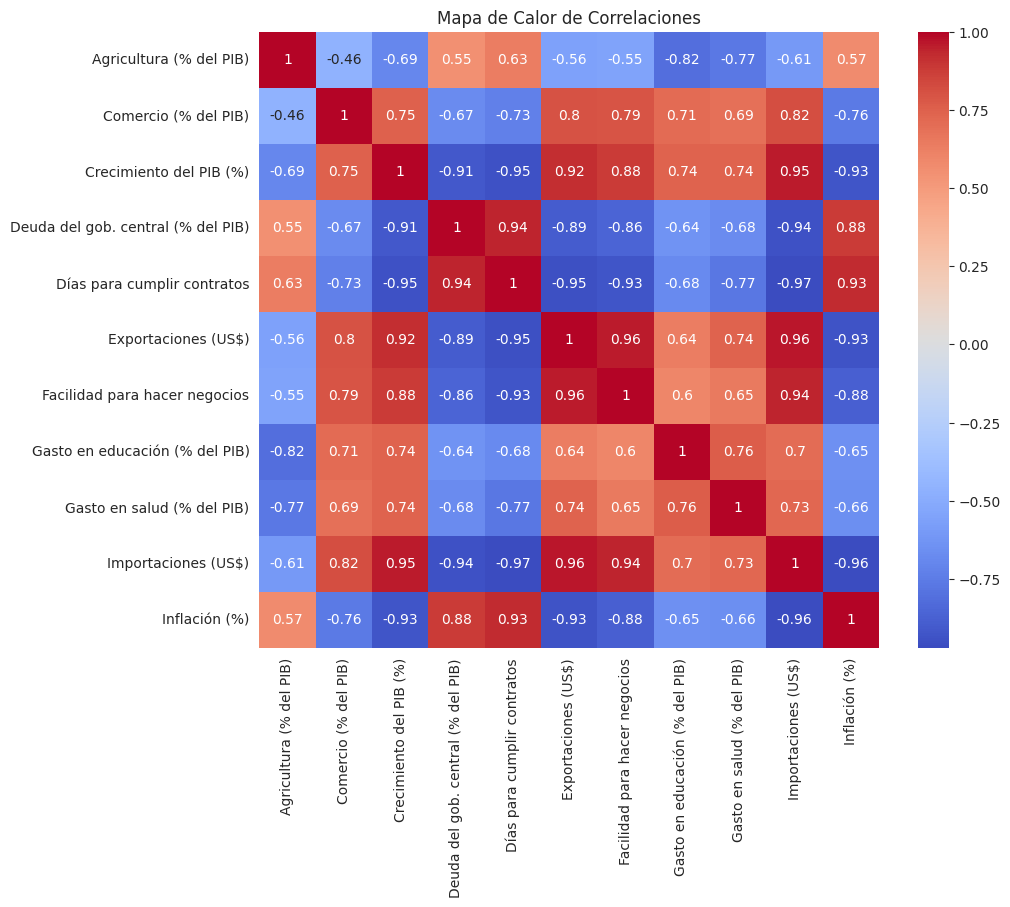

In [45]:
corr = df_final_imputed.corr(numeric_only= True)

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Mapa de Calor de Correlaciones')
plt.show()

4.2. Interpreta los resultados resaltando las correlaciones más relevantes.

**R/**

Las correlaciones positivas más fuertes se observan entre las exportaciones y la facilidad para hacer negocios (0.96), exportaciones e importaciones (0.96), y el crecimiento del PIB con las importaciones (0.95), lo que indica que las economías más dinámicas y abiertas al comercio exterior tienden a crecer más y a operar en entornos institucionales más favorables. Por otro lado, las correlaciones negativas más destacadas se presentan entre los días para cumplir contratos e importaciones (-0.97), el crecimiento del PIB y los días para cumplir contratos (-0.95), y las importaciones con la inflación (-0.96), sugiriendo que una mayor carga burocrática y una inflación elevada están asociadas con menor actividad comercial y menor crecimiento económico. En términos generales, variables como el crecimiento del PIB, el comercio exterior y el entorno institucional emergen como los ejes centrales del análisis, evidenciando que la apertura comercial y la eficiencia institucional son determinantes clave del desempeño económico en el conjunto de datos estudiado.

4.3. Las exportaciones están en miles de millones de dólares y el crecimiento en porcentajes de un dígito. PCA busca varianzas, por lo que estandarizar (Media 0, Desviación 1) es un paso matemático obligatorio para no sesgar el modelo hacia las variables nominales grandes.  Estandariza todas las variables del dataframe y almacena el resultado en X_scaled.

In [46]:
from sklearn.preprocessing import StandardScaler
import numpy as np

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_final_imputed.select_dtypes(include=['float64', 'int64']))

### Ejercicio 5: Aplicación de PCA

Vamos a correr PCA para identificar el número de componentes. Buscamos capturar la mayor cantidad de información (varianza) con la menor cantidad de dimensiones.

5.1. Corre PCA sobre X_scaled y calcula la varianza acumulada. Almacénala en la variable "varianza_acumulada".

In [47]:
#creamos el modelo PCA
pca = PCA()
#ajustamos a los datos escalados
pca.fit(X_scaled)
#calculamos la varianza acumulada
varianza_acumulada = np.cumsum(pca.explained_variance_ratio_)
print(varianza_acumulada)

[0.80432386 0.89486154 0.93597174 0.95991133 0.97641891 0.9864744
 0.99249496 0.99665217 0.99895635 0.99961687 1.        ]


5.2. Similar a como lo vimos en clase, grafica la varianza explicada acumulada por componente.

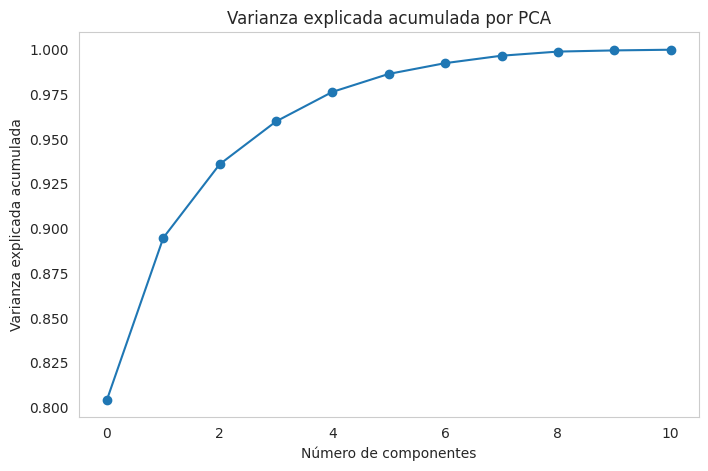

In [48]:
plt.figure(figsize=(8,5))
plt.plot(varianza_acumulada, marker='o')
plt.xlabel('Número de componentes')
plt.ylabel('Varianza explicada acumulada')
plt.title('Varianza explicada acumulada por PCA')
plt.grid()
plt.show()

5.3. Realiza un análisis del gráfico anterior.

**R/**

La gráfica muestra que la mayor parte de la varianza se explica en los primeros componentes. A partir de cierto punto, la ganancia de información adicional es marginal, lo que indica rendimientos decrecientes. Esto sugiere que es posible reducir la dimensionalidad del dataset sin perder una cantidad significativa de información.

### Ejercicio 6: Interpretación Económica de los Componentes (Loadings)

Nos vamos a quedar con un solo componente. Vamor a analizar qué variables originales alimentan a este componente.

6.1. Corre nuevamente el PCA, pero ahora indicando que tenga en cuenta solo 1 componente. Almacena el modelo en "pca_final" y los resultados en "X_pca".

In [49]:
pca_final = PCA(n_components=1)
X_pca = pca_final.fit_transform(X_scaled)

6.2. Grafica el mapa de calor de los loadings como lo vimos en clase

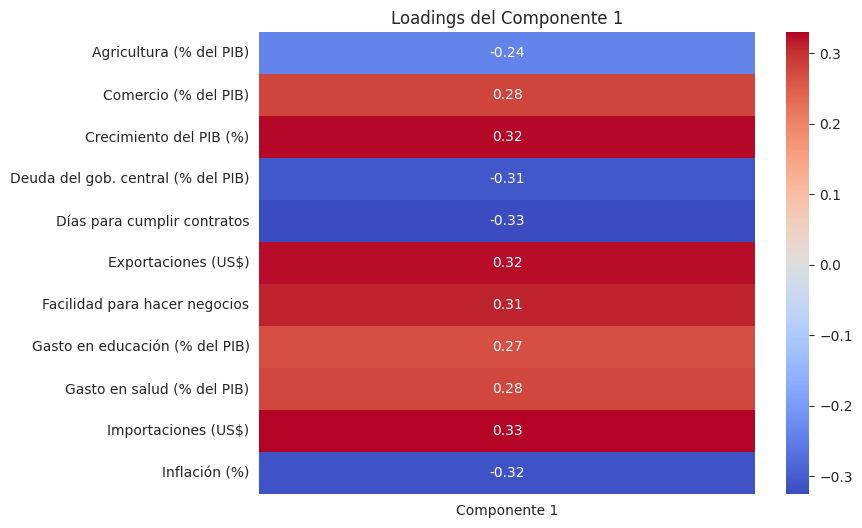

In [50]:
# Obtener loadings
loadings = pd.DataFrame(
    pca_final.components_.T,
    columns=['Componente 1'],
    index=df_final_imputed.select_dtypes(include=['float64','int64']).columns)

plt.figure(figsize=(8,6))
sns.heatmap(loadings, annot=True, cmap='coolwarm')
plt.title('Loadings del Componente 1')
plt.show()

6.3. Realiza una interpretación de los loadings. ¿Cuáles variables tienen las cargas altas y positivas y cuáles las cargas altas y negativas? De acuerdo con este análisis, ¿consideras que efectivamente podemos utilizar el componente 1 como un índice del clima para la inversión en cada país de Latinoamérica? ¿por qué si o por qué no?

**R/**

El gráfico de loadings del Componente 1 permite identificar qué variables contribuyen más a este componente y en qué dirección. Las cargas más altas y positivas corresponden a las importaciones (0.33), el crecimiento del PIB (0.32), las exportaciones (0.32), la facilidad para hacer negocios (0.31), el comercio (0.28) y el gasto en salud (0.28), lo que indica que estas variables se mueven en la misma dirección que el componente: a mayor valor en estas variables, mayor puntuación en el Componente 1. Por su parte, las cargas más altas y negativas pertenecen a los días para cumplir contratos (-0.33), la inflación (-0.32), la deuda del gobierno central (-0.31) y la agricultura (-0.24), señalando que países con mayor burocracia, mayor inflación y mayor deuda pública obtienen puntuaciones más bajas en este componente.

Con base en este análisis, sí es válido utilizar el Componente 1 como un índice del clima para la inversión en países de Latinoamérica, por las siguientes razones: en primer lugar, las variables con cargas positivas altas —como la facilidad para hacer negocios, el crecimiento del PIB y el volumen de comercio exterior— son precisamente los indicadores que los inversionistas consideran favorables al momento de evaluar un destino de inversión. En segundo lugar, las variables con cargas negativas altas —como los días para cumplir contratos, la inflación y la deuda pública— representan obstáculos o riesgos que desincentivan la inversión. El hecho de que el Componente 1 capture de manera coherente esta distinción entre factores que atraen y factores que ahuyentan la inversión lo convierte en un resumen sintético y significativo del entorno económico e institucional de cada país, funcionando así como un índice compuesto del clima de inversión.

### Ejercicio 7: Creación del 'Índice de Clima para la Inversión'

Asignaremos el CP1 como nuestro 'Índice de Clima para la Inversión' y construiremos el ranking regional.

In [51]:
df_final['Indice_Inversion'] = X_pca[:, 0]
df_final.head()

,CountryCode,Agricultura (% del PIB),Comercio (% del PIB),Crecimiento del PIB (%),Deuda del gob. central (% del PIB),Días para cumplir contratos,Exportaciones (US$),Facilidad para hacer negocios,Gasto en educación (% del PIB),Gasto en salud (% del PIB),Importaciones (US$),Inflación (%),ShortName,Region,Indice_Inversion
0,ARG,11.73,32.43,-0.45,73.07,873.48,"20,153,725,105.95",2.19,2.38,4.09,"18,058,208,718.45",44.28,Argentina,Latin America & Caribbean,-5.93
1,BOL,NaN,54.39,1.76,66.69,798.96,"39,036,984,373.93",NaN,5.37,5.05,"36,977,180,000.81",36.05,Bolivia,Latin America & Caribbean,-1.93
2,BRA,12.79,60.18,2.59,57.20,741.68,"56,043,860,610.92",3.57,4.56,5.31,"50,026,448,161.33",25.60,Brasil,Latin America & Caribbean,-1.24
3,CHL,6.75,74.31,7.65,42.83,535.92,"90,542,560,043.59",5.88,6.38,8.29,"80,536,582,307.19",12.62,Chile,Latin America & Caribbean,4.89
4,COL,6.92,59.96,6.60,47.95,633.90,NaN,NaN,6.34,6.30,"67,424,196,254.97",11.61,Colombia,Latin America & Caribbean,2.13


7.1. Ordena el df_final por el índice de clima para la inversión de mayor a menor valor del índice.

In [52]:
df_final = df_final.sort_values(by='Indice_Inversion', ascending=False)
df_final.head()

,CountryCode,Agricultura (% del PIB),Comercio (% del PIB),Crecimiento del PIB (%),Deuda del gob. central (% del PIB),Días para cumplir contratos,Exportaciones (US$),Facilidad para hacer negocios,Gasto en educación (% del PIB),Gasto en salud (% del PIB),Importaciones (US$),Inflación (%),ShortName,Region,Indice_Inversion
3,CHL,6.75,74.31,7.65,42.83,535.92,"90,542,560,043.59",5.88,6.38,8.29,"80,536,582,307.19",12.62,Chile,Latin America & Caribbean,4.89
9,PAN,5.80,NaN,6.89,43.42,555.93,"83,978,447,805.32",5.40,5.95,7.72,"76,338,244,613.60",8.11,Panamá,Latin America & Caribbean,3.89
5,CRI,8.11,70.86,5.88,NaN,610.31,"78,236,959,844.64",5.53,5.64,6.77,"72,324,083,969.39",8.49,Costa Rica,Latin America & Caribbean,2.75
4,COL,6.92,59.96,6.60,47.95,633.90,NaN,NaN,6.34,6.30,"67,424,196,254.97",11.61,Colombia,Latin America & Caribbean,2.13
11,URY,8.21,64.01,4.47,NaN,717.08,"63,598,148,937.21",NaN,5.63,6.65,"59,086,857,093.80",11.66,Uruguay,Latin America & Caribbean,1.09


7.2. Convierte 'ShortName' en una columna del dataframe.

In [53]:
df_final = df_final.reset_index()
df_final.head()

,index,CountryCode,Agricultura (% del PIB),Comercio (% del PIB),Crecimiento del PIB (%),Deuda del gob. central (% del PIB),Días para cumplir contratos,Exportaciones (US$),Facilidad para hacer negocios,Gasto en educación (% del PIB),Gasto en salud (% del PIB),Importaciones (US$),Inflación (%),ShortName,Region,Indice_Inversion
0,3,CHL,6.75,74.31,7.65,42.83,535.92,"90,542,560,043.59",5.88,6.38,8.29,"80,536,582,307.19",12.62,Chile,Latin America & Caribbean,4.89
1,9,PAN,5.80,NaN,6.89,43.42,555.93,"83,978,447,805.32",5.40,5.95,7.72,"76,338,244,613.60",8.11,Panamá,Latin America & Caribbean,3.89
2,5,CRI,8.11,70.86,5.88,NaN,610.31,"78,236,959,844.64",5.53,5.64,6.77,"72,324,083,969.39",8.49,Costa Rica,Latin America & Caribbean,2.75
3,4,COL,6.92,59.96,6.60,47.95,633.90,NaN,NaN,6.34,6.30,"67,424,196,254.97",11.61,Colombia,Latin America & Caribbean,2.13
4,11,URY,8.21,64.01,4.47,NaN,717.08,"63,598,148,937.21",NaN,5.63,6.65,"59,086,857,093.80",11.66,Uruguay,Latin America & Caribbean,1.09


7.3. Utiliza un barplot para mostrar los resultados del Índice de Clima para la Inversión. En el eje y deben ir los países y en el eje X el puntaje del índice. No olvides colocar título al gráfico y a los ejes.

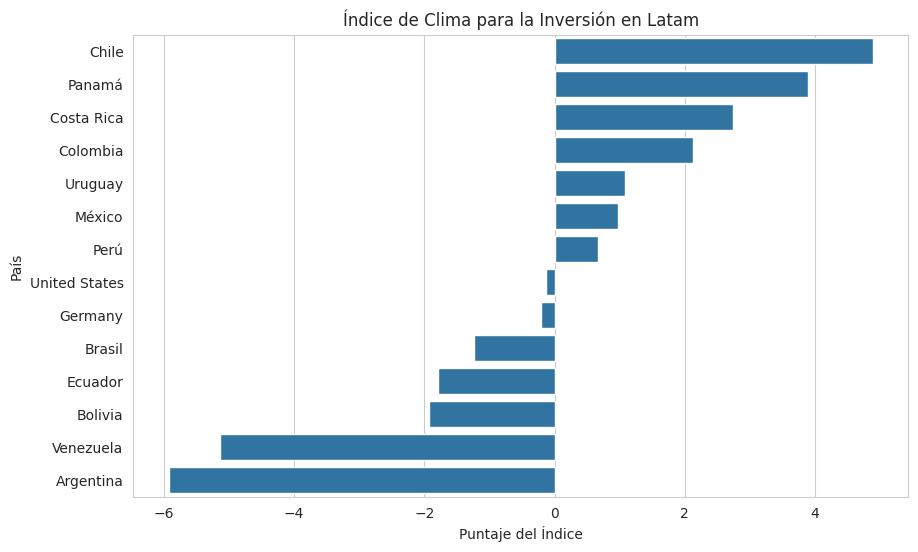

In [54]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Indice_Inversion', y='ShortName', data=df_final)
plt.title('Índice de Clima para la Inversión en Latam')
plt.xlabel('Puntaje del Índice')
plt.ylabel('País')
plt.show()

7.4. Analiza los resultados del gráfico y redacta una conclusiones para el MinCIT sobre el clima de inversión en la región, quiénes son nuestros competidores en la atracción de capitales extranjeros y por qué, en qué son mejores que Colombia.

**R/**

El índice de clima para la inversión en Latinoamérica, construido a partir del Componente 1 del análisis de componentes principales, revela diferencias sustanciales entre los países de la región en términos de su atractivo para la inversión extranjera. Colombia obtiene un puntaje positivo de aproximadamente 2.1, ubicándose en el cuarto lugar de la región, lo cual refleja condiciones relativamente favorables en materia de crecimiento económico, comercio exterior y facilidad para hacer negocios. No obstante, existen tres competidores directos que superan a Colombia de manera significativa y que representan los principales rivales en la atracción de capitales extranjeros.

Chile es el líder indiscutible del índice con un puntaje cercano a 5, lo que lo convierte en el destino más atractivo para la inversión en la región. Su ventaja frente a Colombia radica en una institucionalidad más sólida, menor inflación, menor deuda pública y una mayor facilidad para hacer negocios, factores que generan mayor certeza jurídica y menor riesgo para los inversionistas. Panamá, en segundo lugar con un puntaje aproximado de 4, supera a Colombia principalmente por su posición estratégica como hub logístico y financiero, sus altos volúmenes de comercio exterior y su entorno regulatorio favorable, que reducen significativamente los tiempos y costos de hacer negocios. Costa Rica, en tercer lugar con cerca de 2.7, aventaja a Colombia por su estabilidad macroeconómica, mayor inversión en educación y salud, y un entorno institucional más eficiente que se traduce en menores días para cumplir contratos y mayor confianza del inversionista.

En el extremo opuesto, países como Argentina (-6), Venezuela (-5.5) y Bolivia (-2) presentan los peores climas de inversión de la región, afectados principalmente por alta inflación, elevada deuda pública, excesiva burocracia y baja actividad comercial, lo que los convierte en entornos de alto riesgo para el capital extranjero. Es relevante destacar que incluso economías desarrolladas como Estados Unidos y Alemania aparecen con puntajes cercanos a cero, lo que se explica porque el índice fue construido con variables calibradas para el contexto latinoamericano, donde el tamaño y estructura de esas economías no necesariamente se traduce en ventajas comparativas dentro de este marco de análisis.

En conclusión, si bien Colombia ocupa una posición competitiva dentro de la región, para mejorar su atractivo frente a Chile, Panamá y Costa Rica, el MinCIT debería priorizar políticas orientadas a reducir la carga burocrática en el cumplimiento de contratos, controlar la inflación, racionalizar la deuda pública y fortalecer aún más los indicadores de facilidad para hacer negocios, que son precisamente las dimensiones en las que los líderes regionales presentan mayores fortalezas